In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

%matplotlib inline

In [3]:
oil = yf.download("CL=F", start="2000-01-01")
corn = yf.download("ZC=F", start="2000-01-01")
gas = yf.download("RB=F", start="2000-01-01")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [4]:
oil.to_csv('../data_raw/oil.csv')
corn.to_csv('../data_raw/corn.csv')
gas.to_csv('../data_raw/gasoline.csv')

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

oil_raw = pd.read_csv("../data_raw/oil.csv", header=[0, 1], index_col=0)
corn_raw = pd.read_csv("../data_raw/corn.csv", header=[0, 1], index_col=0)
gas_raw = pd.read_csv("../data_raw/gasoline.csv", header=[0, 1], index_col=0)

In [11]:
print(oil_raw.columns)
print(corn_raw.columns)
print(gas_raw.columns)

oil_raw.head()

MultiIndex([( 'Close', 'CL=F'),
            (  'High', 'CL=F'),
            (   'Low', 'CL=F'),
            (  'Open', 'CL=F'),
            ('Volume', 'CL=F')],
           names=['Price', 'Ticker'])
MultiIndex([( 'Close', 'ZC=F'),
            (  'High', 'ZC=F'),
            (   'Low', 'ZC=F'),
            (  'Open', 'ZC=F'),
            ('Volume', 'ZC=F')],
           names=['Price', 'Ticker'])
MultiIndex([( 'Close', 'RB=F'),
            (  'High', 'RB=F'),
            (   'Low', 'RB=F'),
            (  'Open', 'RB=F'),
            ('Volume', 'RB=F')],
           names=['Price', 'Ticker'])


Price,Close,High,Low,Open,Volume
Ticker,CL=F,CL=F,CL=F,CL=F,CL=F
Date,,,,,
2000-08-23,32.049999,32.799999,31.950001,31.950001,79385
2000-08-24,31.629999,32.240002,31.400000,31.900000,72978
2000-08-25,32.049999,32.099998,31.320000,31.700001,44601
2000-08-28,32.869999,32.919998,31.860001,32.040001,46770
2000-08-29,32.720001,33.029999,32.560001,32.820000,49131


In [14]:
oil = oil_raw[['Close']].copy()
corn = corn_raw[['Close']].copy()
gas = gas_raw[['Close']].copy()

In [15]:
oil.columns = ['Oil']
corn.columns = ['Corn']
gas.columns = ['Gasoline']

In [16]:
oil = oil.reset_index()
corn = corn.reset_index()
gas = gas.reset_index()

In [17]:
oil.head()

,Date,Oil
0,2000-08-23,32.049999
1,2000-08-24,31.629999
2,2000-08-25,32.049999
3,2000-08-28,32.869999
4,2000-08-29,32.720001


In [18]:
oil['Date'] = pd.to_datetime(oil['Date'])
corn['Date'] = pd.to_datetime(corn['Date'])
gas['Date'] = pd.to_datetime(gas['Date'])

In [19]:
oil = oil.sort_values('Date').drop_duplicates(subset='Date')
corn = corn.sort_values('Date').drop_duplicates(subset='Date')
gas = gas.sort_values('Date').drop_duplicates(subset='Date')

In [20]:
print(oil.head())
print(corn.head())
print(gas.head())

print(oil.dtypes)
print(corn.dtypes)
print(gas.dtypes)

print(oil.isna().sum())
print(corn.isna().sum())
print(gas.isna().sum())

        Date        Oil
0 2000-08-23  32.049999
1 2000-08-24  31.629999
2 2000-08-25  32.049999
3 2000-08-28  32.869999
4 2000-08-29  32.720001
        Date    Corn
0 2000-07-17  179.25
1 2000-07-18  180.75
2 2000-07-19  182.00
3 2000-07-20  186.00
4 2000-07-21  187.75
        Date  Gasoline
0 2000-11-01    0.8840
1 2000-11-02    0.8688
2 2000-11-03    0.8695
3 2000-11-06    0.8825
4 2000-11-07    0.8910
Date    datetime64[ns]
Oil            float64
dtype: object
Date    datetime64[ns]
Corn           float64
dtype: object
Date        datetime64[ns]
Gasoline           float64
dtype: object
Date    0
Oil     0
dtype: int64
Date    0
Corn    0
dtype: int64
Date        0
Gasoline    0
dtype: int64


In [21]:
df = oil.merge(corn, on='Date', how='inner')
df = df.merge(gas, on='Date', how='inner')

In [22]:
df.head()
df.tail()

print(df.shape)
print(df.isna().sum())

print(df['Date'].min(), df['Date'].max())

(6355, 4)
Date        0
Oil         0
Corn        0
Gasoline    0
dtype: int64
2000-11-02 00:00:00 2026-04-23 00:00:00


In [25]:
df[['Oil','Corn','Gasoline']].isna().sum()

Oil         0
Corn        0
Gasoline    0
dtype: int64

In [26]:
df['Oil'] = pd.to_numeric(df['Oil'], errors='coerce')
df['Corn'] = pd.to_numeric(df['Corn'], errors='coerce')
df['Gasoline'] = pd.to_numeric(df['Gasoline'], errors='coerce')

In [27]:
df = df.dropna(subset=['Oil','Corn','Gasoline'])

In [28]:
(df[['Oil','Corn','Gasoline']] <= 0).sum()

Oil         1
Corn        0
Gasoline    0
dtype: int64

In [29]:
df = df[(df['Oil'] > 0) & (df['Corn'] > 0) & (df['Gasoline'] > 0)]

In [30]:
df['Oil_ret'] = np.log(df['Oil'] / df['Oil'].shift(1))
df['Corn_ret'] = np.log(df['Corn'] / df['Corn'].shift(1))
df['Gasoline_ret'] = np.log(df['Gasoline'] / df['Gasoline'].shift(1))

In [31]:
df = df.dropna()

In [32]:
df[['Oil_ret','Corn_ret','Gas_ret']].describe()

,Oil_ret,Corn_ret,Gas_ret
count,6353.000000,6353.000000,6353.000000
mean,0.000167,0.000130,0.000218
std,0.027286,0.017997,0.027337
min,-0.601676,-0.268620,-0.385352
25%,-0.012662,-0.009413,-0.012719
50%,0.001084,0.000000,0.001192
75%,0.013487,0.009627,0.014465
max,0.319634,0.127571,0.223966


In [34]:
df.loc[df['Corn_ret'] < -0.2]

,Date,Oil,Corn,Gasoline,Oil_ret,Corn_ret,Gas_ret,Gasoline_ret
3145,2013-07-15,106.32,536.25,3.1029,0.003486,-0.26862,-0.004694,-0.004694


In [35]:
df.loc[df['Oil_ret'] < -0.5]

,Date,Oil,Corn,Gasoline,Oil_ret,Corn_ret,Gas_ret,Gasoline_ret
4845,2020-04-21,10.01,309.25,0.5103,-0.601676,-0.041178,-0.269738,-0.331252


In [36]:
df = df[(df['Corn_ret'] > -0.2) & (df['Corn_ret'] < 0.2)]
df = df[(df['Oil_ret'] > -0.6) & (df['Oil_ret'] < 0.6)]
df = df[(df['Gas_ret'] > -0.4) & (df['Gas_ret'] < 0.4)]

In [37]:
df[['Oil_ret','Corn_ret','Gas_ret']].describe()

,Oil_ret,Corn_ret,Gas_ret
count,6351.000000,6351.000000,6351.000000
mean,0.000261,0.000179,0.000261
std,0.026225,0.017674,0.027131
min,-0.282206,-0.190997,-0.385352
25%,-0.012657,-0.009400,-0.012712
50%,0.001084,0.000000,0.001204
75%,0.013490,0.009634,0.014467
max,0.319634,0.127571,0.223966


In [38]:
df[['Oil_ret','Corn_ret','Gas_ret']].corr()

,Oil_ret,Corn_ret,Gas_ret
Oil_ret,1.000000,0.190661,0.700450
Corn_ret,0.190661,1.000000,0.148693
Gas_ret,0.700450,0.148693,1.000000


array([[<Axes: title={'center': 'Oil_ret'}>,
        <Axes: title={'center': 'Corn_ret'}>],
       [<Axes: title={'center': 'Gas_ret'}>, <Axes: >]], dtype=object)

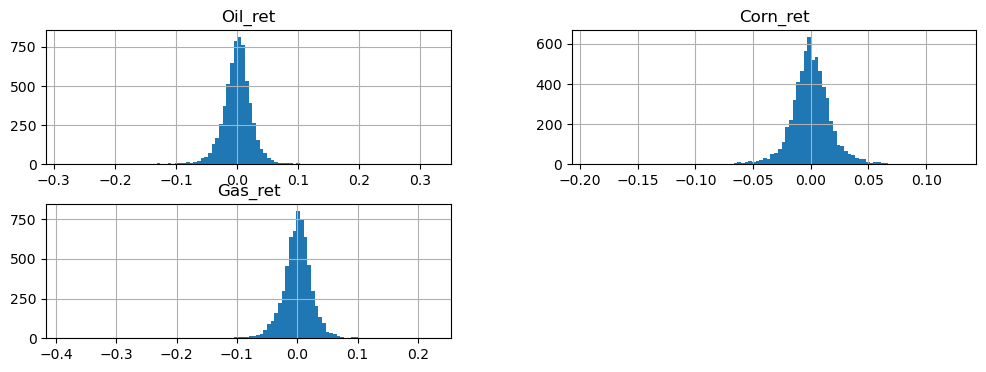

In [39]:
df[['Oil_ret','Corn_ret','Gas_ret']].hist(bins=100, figsize=(12,4))

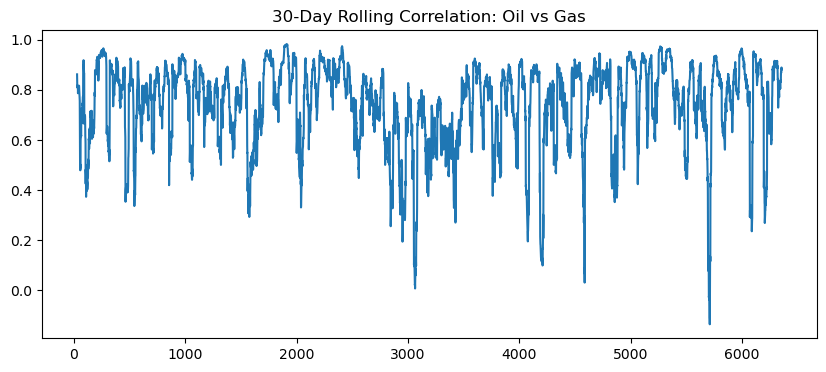

In [41]:
rolling_corr = df['Oil_ret'].rolling(30).corr(df['Gas_ret'])

rolling_corr.plot(figsize=(10,4))
plt.title("30-Day Rolling Correlation: Oil vs Gas")
plt.show()

In [42]:
df[['Oil_ret','Gas_ret']].corr()

,Oil_ret,Gas_ret
Oil_ret,1.00000,0.70045
Gas_ret,0.70045,1.00000


In [43]:
df.to_csv('../data_clean/merged_returns.csv', index=False)